In [1]:
# Required Libraries
import time
import itertools
import matplotlib.pyplot as plt
from memory_profiler import memory_usage



In [2]:
# Flights: (Flight_ID, Start_Time, End_Time)
flights = [
    ('F1', 9, 11),
    ('F2', 10, 12),
    ('F3', 11, 13),
    ('F4', 12, 14)
]

# Crew Members
crew_members = ['C1', 'C2', 'C3']

# Constraint Check Function
def is_valid(crew_schedule, crew, flight):
    for assigned_flight in crew_schedule.get(crew, []):
        # Check overlap
        if not (flight[1] >= assigned_flight[2] or flight[2] <= assigned_flight[1]):
            return False
    return True

In [3]:
def backtrack_schedule(flights, crew_members, crew_schedule, index=0):
    if index == len(flights):
        return crew_schedule

    flight = flights[index]

    for crew in crew_members:
        if is_valid(crew_schedule, crew, flight):
            crew_schedule.setdefault(crew, []).append(flight)

            result = backtrack_schedule(flights, crew_members, crew_schedule, index + 1)
            if result:
                return result

            # Backtrack
            crew_schedule[crew].remove(flight)

    return None

# Run Backtracking
schedule = backtrack_schedule(flights, crew_members, {})

print("Backtracking Schedule:")
print(schedule)

Backtracking Schedule:
{'C1': [('F1', 9, 11), ('F3', 11, 13)], 'C2': [('F2', 10, 12), ('F4', 12, 14)]}


In [4]:
best_solution = None
best_cost = float('inf')

def branch_and_bound(flights, crew_members, crew_schedule={}, index=0, cost=0):
    global best_solution, best_cost

    if cost >= best_cost:
        return

    if index == len(flights):
        best_solution = crew_schedule.copy()
        best_cost = cost
        return

    flight = flights[index]

    for crew in crew_members:
        if is_valid(crew_schedule, crew, flight):
            crew_schedule.setdefault(crew, []).append(flight)

            branch_and_bound(
                flights,
                crew_members,
                crew_schedule,
                index + 1,
                cost + 1
            )

            crew_schedule[crew].remove(flight)

# Run Branch and Bound
branch_and_bound(flights, crew_members)

print("Best Solution (Branch & Bound):")
print(best_solution)

Best Solution (Branch & Bound):
{'C1': [], 'C2': []}


In [5]:
def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0

    for i in range(n - m + 1):
        for j in range(m):
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
        else:
            print(f"Pattern found at index {i}")

    return comparisons

# Test
text = "ABABDABACDABABCABAB"
pattern = "ABABCABAB"

comp_naive = naive_search(text, pattern)
print("Naive Comparisons:", comp_naive)

Pattern found at index 10
Naive Comparisons: 29


In [6]:
def compute_lps(pattern):
    lps = [0] * len(pattern)
    length = 0
    i = 1

    while i < len(pattern):
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
    return lps


def kmp_search(text, pattern):
    lps = compute_lps(pattern)
    i = j = 0
    comparisons = 0

    while i < len(text):
        comparisons += 1

        if pattern[j] == text[i]:
            i += 1
            j += 1

        if j == len(pattern):
            print(f"KMP found pattern at index {i - j}")
            j = lps[j - 1]

        elif i < len(text) and pattern[j] != text[i]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return comparisons

# Test
comp_kmp = kmp_search(text, pattern)
print("KMP Comparisons:", comp_kmp)

KMP found pattern at index 10
KMP Comparisons: 21


Pattern found at index 99
KMP found pattern at index 99
Pattern found at index 199
KMP found pattern at index 199
Pattern found at index 299
KMP found pattern at index 299
Pattern found at index 399
KMP found pattern at index 399
Pattern found at index 499
KMP found pattern at index 499


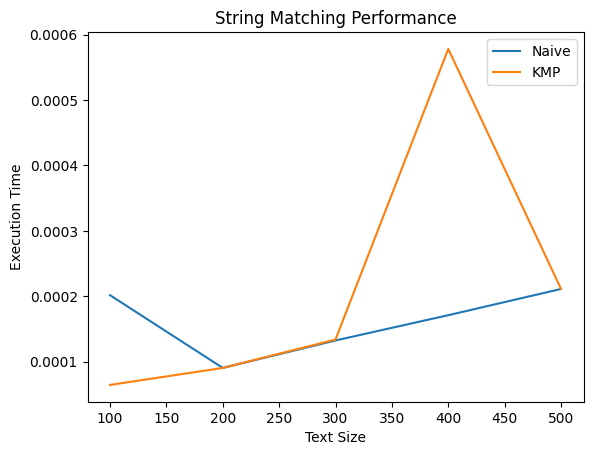

In [7]:
sizes = [100, 200, 300, 400, 500]
naive_times = []
kmp_times = []

for size in sizes:
    text = "A" * size + "B"
    pattern = "AB"

    # Naive
    start = time.time()
    naive_search(text, pattern)
    naive_times.append(time.time() - start)

    # KMP
    start = time.time()
    kmp_search(text, pattern)
    kmp_times.append(time.time() - start)

# Plot
plt.plot(sizes, naive_times, label="Naive")
plt.plot(sizes, kmp_times, label="KMP")
plt.xlabel("Text Size")
plt.ylabel("Execution Time")
plt.legend()
plt.title("String Matching Performance")
plt.show()

In [8]:
mem_usage = memory_usage((backtrack_schedule, (flights, crew_members, {})))
print("Memory Usage (Backtracking):", max(mem_usage), "MB")

Memory Usage (Backtracking): 119.0078125 MB
